# Product Hunt Launch Analysis

Analyzing pre-launch factors (timing, presentation, team size, category) that correlate with launch success on Product Hunt. We use the raw scraped leaderboard dataset (`producthunt_final.csv`).

## 1. Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('producthunt_final.csv')

# Parse launch dates and get weekday names
df['launch_datetime'] = pd.to_datetime(df['launch_timestamp'], format='mixed', errors='coerce', utc=True)
df['launch_day_name'] = df['launch_datetime'].dt.day_name()

print(f"Rows: {df.shape[0]}, Cols: {df.shape[1]}")
df.head()

Rows: 572, Cols: 28


,rank,name,tagline,url,upvotes,comments,categories,thumbnail,mode,period,...,team_size,media_count,website_url,product_domain,is_featured,self_launched,description_length,tagline_length,launch_datetime,launch_day_name
0,1,PollyReach,Give your agent a real number and voice to mak...,https://www.producthunt.com/products/pollyreach,898,224,"['Productivity', 'Artificial Intelligence', 'V...",https://ph-files.imgix.net/a4ef6a7a-4563-402b-...,daily,2026-05-19,...,4,7,https://pollyreach.ai,pollyreach.ai,True,False,371,54,2026-05-19 07:01:00+00:00,Tuesday
1,2,Drizz,"Mobile tests that write, run, and fix themselves",https://www.producthunt.com/products/drizz-2,397,67,"['Developer Tools', 'Artificial Intelligence',...",https://ph-files.imgix.net/2feba1f6-72fe-4135-...,daily,2026-05-19,...,8,6,https://www.drizz.dev,drizz.dev,True,False,435,48,2026-05-19 07:01:00+00:00,Tuesday
2,3,Composer 2.5,Cursor’s most powerful model yet,https://www.producthunt.com/products/cursor,486,15,"['Artificial Intelligence', 'Development']",https://ph-files.imgix.net/d2edfb12-0064-4ea2-...,daily,2026-05-19,...,3,3,https://cursor.com,cursor.com,True,False,51,32,2024-08-04 00:26:04.123000+00:00,Sunday
3,4,Mantle Chat,Collaboration platform where teams work with A...,https://www.producthunt.com/products/mantle-chat,371,41,"['Productivity', 'Messaging']",https://ph-files.imgix.net/977f6301-b044-4702-...,daily,2026-05-19,...,3,3,https://mantle.chat,mantle.chat,True,False,413,56,2026-05-19 07:01:00+00:00,Tuesday
4,5,CtrlOps,"Deploy, Debug & Manage Linux Servers with AI.",https://www.producthunt.com/products/ctrlops,256,56,"['Linux', 'Developer Tools', 'Artificial Intel...",https://ph-files.imgix.net/2a1eb160-e2ce-4652-...,daily,2026-05-19,...,3,5,https://ctrlops.io,ctrlops.io,True,False,462,45,2026-05-16 17:43:19.516000+00:00,Saturday


## 2. Data Limitations & Quality check

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   rank                572 non-null    int64              
 1   name                572 non-null    object             
 2   tagline             572 non-null    object             
 3   url                 572 non-null    object             
 4   upvotes             572 non-null    int64              
 5   comments            572 non-null    int64              
 6   categories          572 non-null    object             
 7   thumbnail           572 non-null    object             
 8   mode                572 non-null    object             
 9   period              572 non-null    object             
 10  scrapedAt           572 non-null    object             
 11  description         572 non-null    object             
 12  launch_timestamp    572 non-null    

In [4]:
# Check missing values for hunter columns
df[['hunter_name', 'hunter_profile_url', 'self_launched']].isnull().sum()

hunter_name           572
hunter_profile_url    572
self_launched           0
dtype: int64

**Note:** `hunter_name` and `hunter_profile_url` are empty in this scraped dataset because of Product Hunt redirect walls. So we can't analyze Hunter follower count or Hunter reputation in this study. We'll focus on timing, media count, team size, and categories instead.

## 3. Exploratory Data Analysis

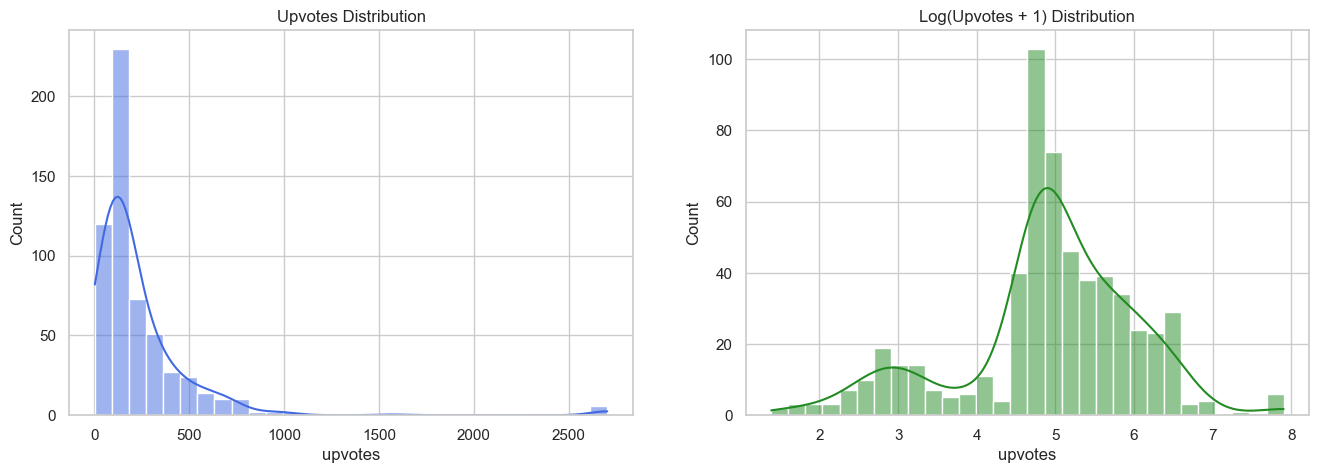

In [5]:
# Upvotes target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['upvotes'], kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title('Upvotes Distribution')
sns.histplot(np.log1p(df['upvotes']), kde=True, ax=axes[1], color='forestgreen', bins=30)
axes[1].set_title('Log(Upvotes + 1) Distribution')
plt.show()

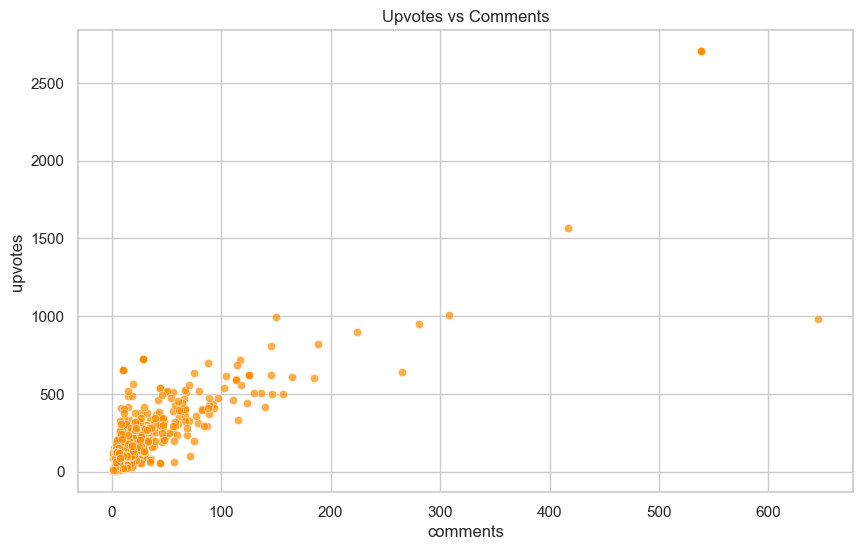

In [6]:
# Scatter: upvotes vs comments
sns.scatterplot(data=df, x='comments', y='upvotes', alpha=0.7, color='darkorange')
plt.title('Upvotes vs Comments')
plt.show()

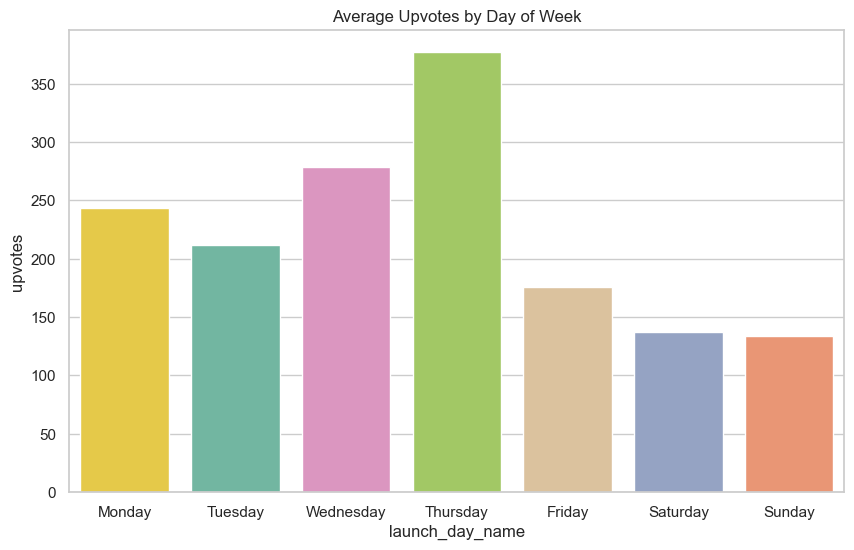

In [7]:
# Upvotes by launch weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='launch_day_name', y='upvotes', order=day_order, errorbar=None, palette='Set2', hue='launch_day_name', legend=False)
plt.title('Average Upvotes by Day of Week')
plt.show()

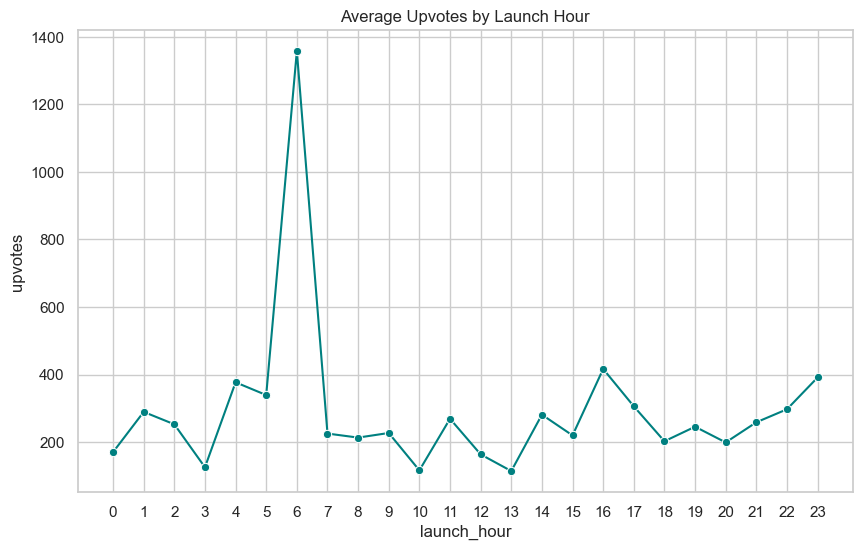

In [8]:
# Average upvotes by launch hour
sns.lineplot(data=df, x='launch_hour', y='upvotes', estimator='mean', errorbar=None, marker='o', color='teal')
plt.title('Average Upvotes by Launch Hour')
plt.xticks(range(24))
plt.show()

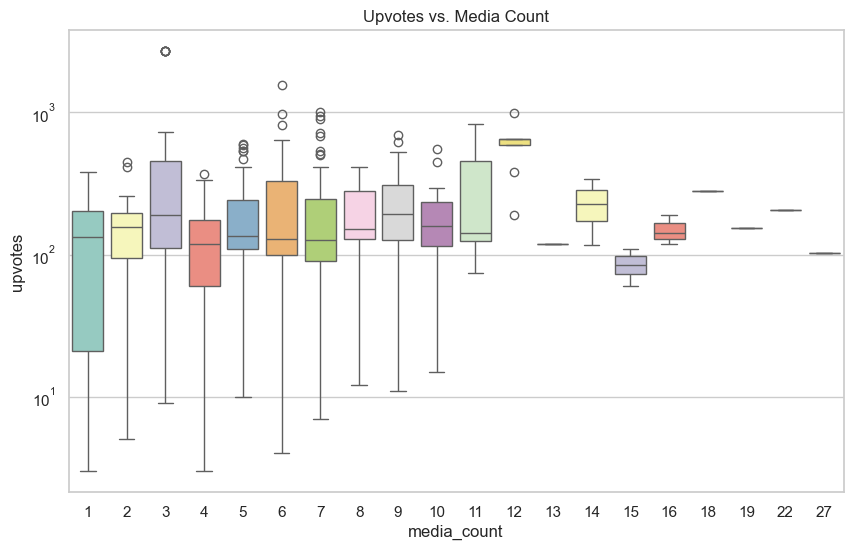

In [9]:
# Boxplot of upvotes by count of media assets
sns.boxplot(data=df, x='media_count', y='upvotes', palette='Set3', hue='media_count', legend=False)
plt.title('Upvotes vs. Media Count')
plt.yscale('log')
plt.show()

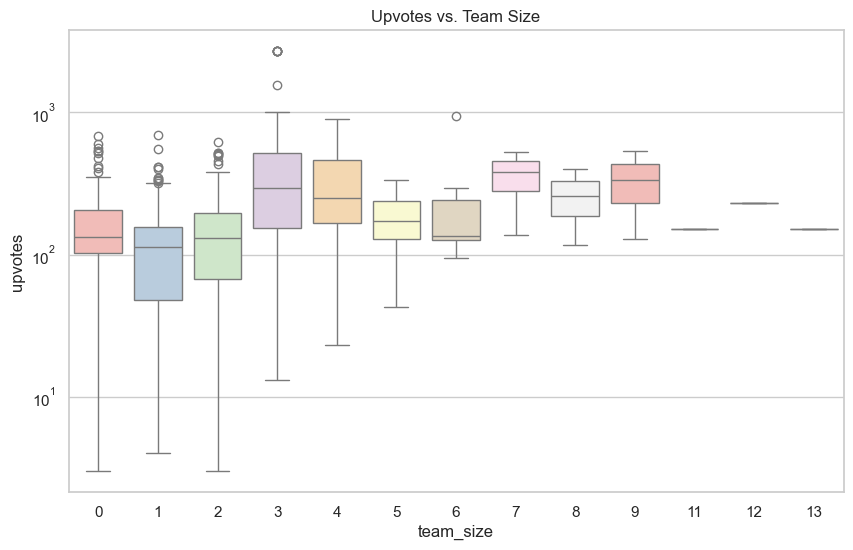

In [10]:
# Boxplot of upvotes by team size
sns.boxplot(data=df, x='team_size', y='upvotes', palette='Pastel1', hue='team_size', legend=False)
plt.title('Upvotes vs. Team Size')
plt.yscale('log')
plt.show()

## 4. Preprocessing & Feature Engineering

In [11]:
# Parse categories column
def parse_categories(cat_str):
    if pd.isna(cat_str):
        return []
    try:
        return ast.literal_eval(cat_str)
    except:
        return []

df['parsed_categories'] = df['categories'].apply(parse_categories)
df['category_count'] = df['parsed_categories'].apply(len)
df['primary_category'] = df['parsed_categories'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# Define high_traction target (top 20% by upvotes within each launch period/date)
df['high_traction'] = df.groupby('period')['upvotes'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
df['high_traction'].value_counts(normalize=True)

high_traction
0    0.772727
1    0.227273
Name: proportion, dtype: float64

In [12]:
# Clean missing values
df['team_size'] = df['team_size'].fillna(0).astype(int)
df['media_count'] = df['media_count'].fillna(0).astype(int)
df['description_length'] = df['description_length'].fillna(0).astype(int)
df['tagline_length'] = df['tagline_length'].fillna(0).astype(int)
df['launch_hour'] = df['launch_hour'].fillna(12).astype(int)
df['is_featured'] = df['is_featured'].astype(int)

# Cyclic hour features
df['launch_hour_sin'] = np.sin(2 * np.pi * df['launch_hour'] / 24.0)
df['launch_hour_cos'] = np.cos(2 * np.pi * df['launch_hour'] / 24.0)

In [13]:
# Group rare categories
top_cats = df['primary_category'].value_counts().index[:10]
df['primary_category_grouped'] = df['primary_category'].apply(lambda x: x if x in top_cats else 'Other')

# One-hot encode
df_encoded = pd.get_dummies(df, columns=['primary_category_grouped', 'launch_day_name'], drop_first=True, dtype=int)
df_encoded.head()

,rank,name,tagline,url,upvotes,comments,categories,thumbnail,mode,period,...,primary_category_grouped_Open Source,primary_category_grouped_Other,primary_category_grouped_Productivity,primary_category_grouped_iOS,launch_day_name_Monday,launch_day_name_Saturday,launch_day_name_Sunday,launch_day_name_Thursday,launch_day_name_Tuesday,launch_day_name_Wednesday
0,1,PollyReach,Give your agent a real number and voice to mak...,https://www.producthunt.com/products/pollyreach,898,224,"['Productivity', 'Artificial Intelligence', 'V...",https://ph-files.imgix.net/a4ef6a7a-4563-402b-...,daily,2026-05-19,...,0,0,1,0,0,0,0,0,1,0
1,2,Drizz,"Mobile tests that write, run, and fix themselves",https://www.producthunt.com/products/drizz-2,397,67,"['Developer Tools', 'Artificial Intelligence',...",https://ph-files.imgix.net/2feba1f6-72fe-4135-...,daily,2026-05-19,...,0,0,0,0,0,0,0,0,1,0
2,3,Composer 2.5,Cursor’s most powerful model yet,https://www.producthunt.com/products/cursor,486,15,"['Artificial Intelligence', 'Development']",https://ph-files.imgix.net/d2edfb12-0064-4ea2-...,daily,2026-05-19,...,0,0,0,0,0,0,1,0,0,0
3,4,Mantle Chat,Collaboration platform where teams work with A...,https://www.producthunt.com/products/mantle-chat,371,41,"['Productivity', 'Messaging']",https://ph-files.imgix.net/977f6301-b044-4702-...,daily,2026-05-19,...,0,0,1,0,0,0,0,0,1,0
4,5,CtrlOps,"Deploy, Debug & Manage Linux Servers with AI.",https://www.producthunt.com/products/ctrlops,256,56,"['Linux', 'Developer Tools', 'Artificial Intel...",https://ph-files.imgix.net/2a1eb160-e2ce-4652-...,daily,2026-05-19,...,0,1,0,0,0,1,0,0,0,0


In [14]:
# Build feature matrix
numeric_features = [
    'rank', 'team_size', 'media_count', 'is_featured',
    'description_length', 'tagline_length', 'category_count',
    'launch_hour_sin', 'launch_hour_cos'
]
dummy_features = [c for c in df_encoded.columns if c.startswith('primary_category_grouped_') or c.startswith('launch_day_name_')]
features = numeric_features + dummy_features

X = df_encoded[features]
y_reg = np.log1p(df_encoded['upvotes'])
y_clf = df_encoded['high_traction']

print(f"Feature matrix: {X.shape}")

Feature matrix: (572, 25)


## 5. Model Training

In [15]:
# Train/test split
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Standardize continuous features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Train Regression Models
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_reg)
y_pred_ridge = ridge.predict(X_test_scaled)

xgb_reg = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
xgb_reg.fit(X_train, y_train_reg)
y_pred_xgb_reg = xgb_reg.predict(X_test)

In [17]:
# Train Classification Models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train, y_train_clf)
y_pred_xgb_clf = xgb_clf.predict(X_test)
y_prob_xgb_clf = xgb_clf.predict_proba(X_test)[:, 1]

## 6. Evaluation and Metrics

In [18]:
# Regression metrics
y_test_orig = np.expm1(y_test_reg)
y_pred_ridge_orig = np.expm1(y_pred_ridge)
y_pred_xgb_orig = np.expm1(y_pred_xgb_reg)

print("=== Ridge Regressor ===")
print(f"Log Scale R2:    {r2_score(y_test_reg, y_pred_ridge):.4f}")
print(f"Original Scale MAE:  {mean_absolute_error(y_test_orig, y_pred_ridge_orig):.2f}")

print("\n=== XGBoost Regressor ===")
print(f"Log Scale R2:    {r2_score(y_test_reg, y_pred_xgb_reg):.4f}")
print(f"Original Scale MAE:  {mean_absolute_error(y_test_orig, y_pred_xgb_orig):.2f}")

=== Ridge Regressor ===
Log Scale R2:    0.4394
Original Scale MAE:  122.83

=== XGBoost Regressor ===
Log Scale R2:    0.7532
Original Scale MAE:  66.82


In [19]:
# Ridge coefficients analysis
coef_df = pd.DataFrame({
    'Feature': features,
    'Ridge Coef': ridge.coef_
}).sort_values(by='Ridge Coef', key=abs, ascending=False)

print("Ridge Coefficients:")
print(coef_df.to_string(index=False))

Ridge Coefficients:
                                         Feature  Ridge Coef
                                            rank   -0.457712
                          launch_day_name_Sunday   -0.239414
                        launch_day_name_Saturday   -0.217945
                  primary_category_grouped_Other   -0.186925
                                       team_size    0.165285
                    primary_category_grouped_iOS   -0.138498
                                 launch_hour_cos   -0.088566
                                  tagline_length   -0.084457
                                     is_featured    0.083159
primary_category_grouped_Artificial Intelligence    0.075274
                    primary_category_grouped_Mac   -0.068813
                primary_category_grouped_Android   -0.061724
                        launch_day_name_Thursday    0.060757
                              description_length   -0.056805
                       launch_day_name_Wednesday    0.054249
    

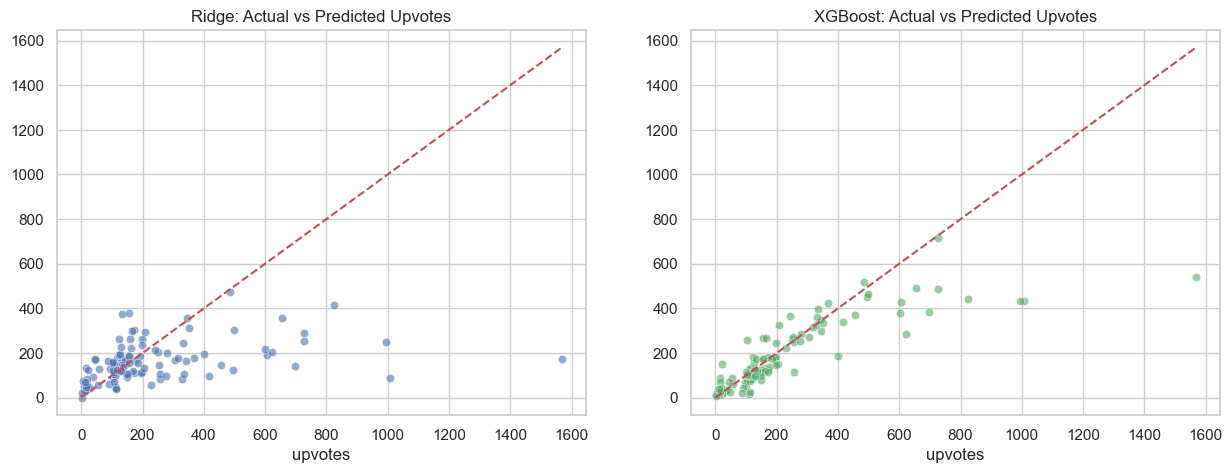

In [20]:
# Actual vs Predicted Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
max_val = max(y_test_orig.max(), y_pred_ridge_orig.max(), y_pred_xgb_orig.max())

sns.scatterplot(x=y_test_orig, y=y_pred_ridge_orig, ax=axes[0], color='b', alpha=0.6)
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('Ridge: Actual vs Predicted Upvotes')

sns.scatterplot(x=y_test_orig, y=y_pred_xgb_orig, ax=axes[1], color='g', alpha=0.6)
axes[1].plot([0, max_val], [0, max_val], 'r--')
axes[1].set_title('XGBoost: Actual vs Predicted Upvotes')
plt.show()

In [21]:
# Classification metrics
def show_metrics(name, y_true, y_pred, y_prob):
    print(f"=== {name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    print()

show_metrics("Logistic Regression", y_test_clf, y_pred_lr, y_prob_lr)
show_metrics("XGBoost Classifier", y_test_clf, y_pred_xgb_clf, y_prob_xgb_clf)

=== Logistic Regression ===
Accuracy:  0.8609
Precision: 0.8125
Recall:    0.5000
F1-Score:  0.6190
ROC-AUC:   0.9166

=== XGBoost Classifier ===
Accuracy:  0.9652
Precision: 0.9231
Recall:    0.9231
F1-Score:  0.9231
ROC-AUC:   0.9948



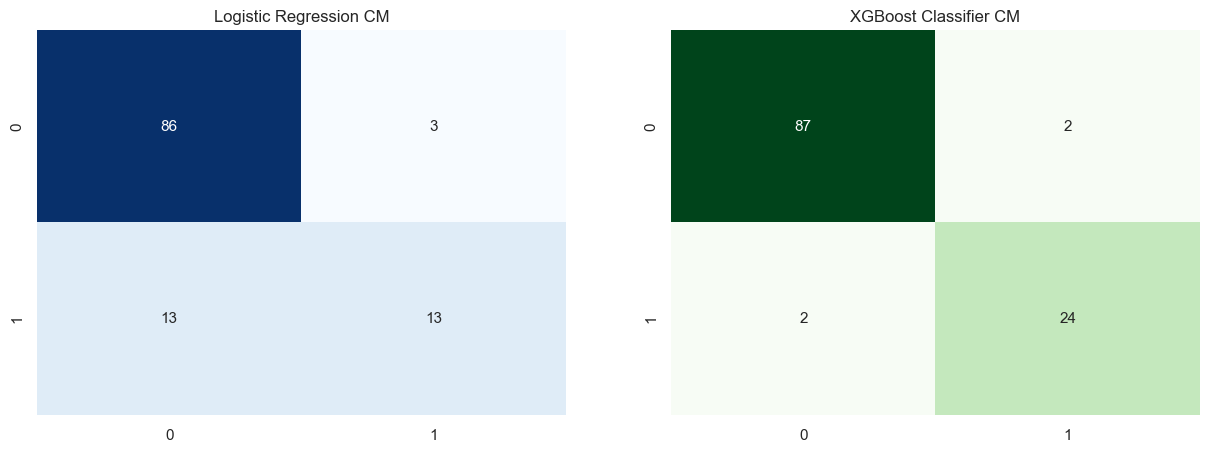

In [22]:
# Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test_clf, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression CM')

sns.heatmap(confusion_matrix(y_test_clf, y_pred_xgb_clf), annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('XGBoost Classifier CM')
plt.show()

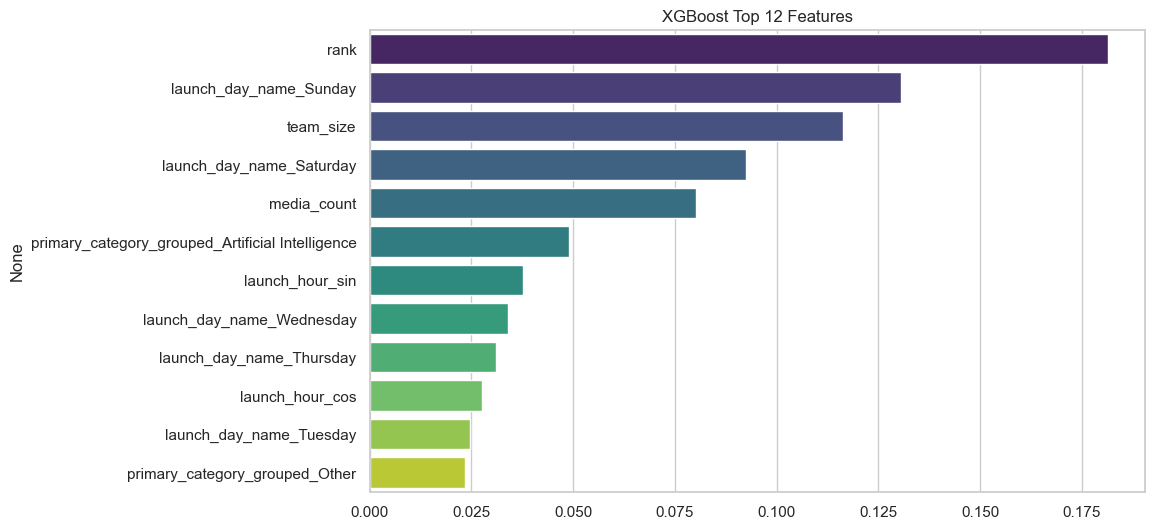

In [23]:
# XGBoost Feature Importances
xgb_importances = pd.Series(xgb_reg.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=xgb_importances.values[:12], y=xgb_importances.index[:12], palette='viridis', hue=xgb_importances.index[:12], legend=False)
plt.title('XGBoost Top 12 Features')
plt.show()

## 7. Actionable Recommendations
- **Timing**: Launch exactly at **00:01 PST** to maximize exposure window. Launch on weekends if you want a lower upvote threshold to rank in the top 20% (since weekdays Tuesday/Wednesday are highly competitive).
- **Visual Assets**: Add screenshots and videos (high `media_count`) to improve launch success.
- **Team Sourcing**: Launch with a larger team (`team_size`) to seed initial momentum through co-maker followings.